**This code use Distilbert model for Covid19 datasets (CgatGPT-generated data, AND Falcon-generated dataset) with three main experiments:**


1.   **Experiment1**: train the model using original dataset and test it on original set
2.   **Experiment2**: train the model using synthetic dataset and test it on original set then synth set
3.   **Experiment3**: train the model using merge dataset and test it on original set




In [1]:
!pip install torch
!pip install transformers
!pip install pandas
!pip install emoji

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 28.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.8/268.8 kB 29.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 75.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 60.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 358.9/358.9 kB 6.0 MB/s eta 0:00:00


In [2]:
## Import Basics
import pandas as pd
import numpy as np
import string
import emoji
import re
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import DataLoader, Dataset
from sklearn.utils import shuffle
from transformers import AutoTokenizer, AutoModelForSequenceClassification, AdamW
from sklearn.metrics import classification_report
from transformers import AutoTokenizer, AutoModel
from textblob import TextBlob
from sklearn.utils import shuffle
from sklearn.metrics import confusion_matrix
from sklearn.metrics import confusion_matrix

In [18]:
#Select the dataset to train the model

#Experiment1:
#selected_train_dataset='Real_covid19_train_tweets.csv' #original trainig set
#selected_test_dataset='Real_covid19_test_283.csv'  #original testing set

#Experiment2:
#for ChatGPT data:
#selected_train_dataset='ChatGPT_synth_train_covid.csv' #ChatGPT's generated data (training set)
#selected_test_dataset='Real_covid19_test_283.csv'  #original testing set
#selected_ChatGPT_test_dataset='ChatGPT_synth_test_covid.csv'  #ChatGPT's generated data (testing set)
#for Falcon data:
selected_train_dataset='FALCON_synth_train_covid.csv'           #Falcon's  generated data (training set)
selected_test_dataset='Real_covid19_test_283.csv'  #original testing set
selected_Falcon_test_dataset='FALCON_synth_test_covid.csv'            #Falcon's  generated data (testing set)

#Experiment3:
#for ChatGPT merge
#selected_train_dataset='ChatGPT_merge_covid.csv'      #ChatGPT's generated data merge with original training set
#selected_test_dataset='Real_covid19_test_283.csv'  #original testing set
#for Falcon data
#selected_train_dataset='FALCON_merge_covid.csv'          #Falcon's generated data merge with original training set
#selected_test_dataset='Real_covid19_test_283.csv'  #original testing set


For the sake of simplicity, I
we will present one experiment, as all other experiments follow the same steps with changes in the dataset. However, we will present the results of each experiment.

**The following presents the main steps for each experiment:**

#1. Load the datasets

In [33]:
traindf = pd.read_csv(selected_train_dataset)

In [34]:
testdf = pd.read_csv(selected_test_dataset)

In [35]:
testdf_synth= pd.read_csv(selected_Falcon_test_dataset) #for Experiment2 to test on synthetic data (Falcon or ChatGPT)

In [36]:
traindf.head()

,tweet,label
0,I wouldn't get vaccinated if you paid me.,0
1,Pfizer and BioNTech's COVID-19 vaccine is a re...,0
2,The vaccine is just a cover-up for a governmen...,0
3,COVID-19 vaccine is a way to spread the virus ...,0
4,Covid-19 vaccines are the perfect way to make ...,0


In [22]:
#rearrange the dataset randomly
traindf = shuffle(traindf, random_state=42)
testdf = shuffle(testdf, random_state=42)
#testdf_synth=shuffle(testdf_synth, random_state=42) #for exp2

In [23]:
traindf.head() # 0:Against,  1:None,  2:Favor

,tweet,label
1373,moderna vaccine found highly effective against...,2
499,USERNAME there is no covid19 cure this is a li...,0
795,care homes to be first to receive coronavirus ...,1
251,na that vaccine go kill you u dey there with y...,0
23,any vaccine suddenly being introduced that too...,0


#2. Visualizing the dataset

In [37]:
traindf['label'].value_counts()

2    334
0    333
1    333
Name: label, dtype: int64

In [38]:
testdf['label'].value_counts()

2    94
1    94
0    94
Name: label, dtype: int64

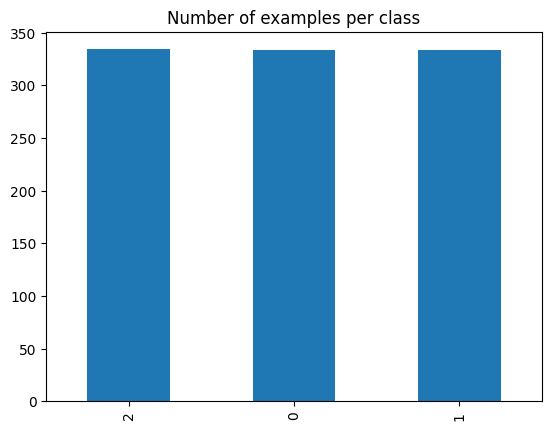

In [39]:
traindf['label'].value_counts().sort_values(ascending=False).plot(kind="bar")
plt.title("Number of examples per class");

In [40]:
traindf.shape,  testdf.shape,

((1000, 2), (282, 2))

In [41]:
testdf_synth.shape #(for expr2)

(282, 2)

#3. Data Pre-processing

In [29]:

#clean the tweets
def preprocess(datatw):
    text = datatw.lower()  # convert to lowercase
    text = re.sub(r"http\S+|www\S+|https\S+", " ", text)  # remove URLs
    text = re.sub(r"@\w+", "<USERNAME>", text)  # normalize usernames
    text = text.translate(str.maketrans("", "", string.punctuation))  # remove punctuation
    text = emoji.demojize(text)  # remove emojis
    text = re.sub(r"(:[\w\d]+:)", "", text)  # remove emoji codes
    text = re.sub(r"\s+", " ", text).strip()  # remove extra whitespace

    return text


In [30]:
# apply preprocessing
traindf['tweet'] = traindf['tweet'].apply(preprocess)

In [31]:
traindf.head()

,tweet,label
1373,moderna vaccine found highly effective against...,2
499,username there is no covid19 cure this is a li...,0
795,care homes to be first to receive coronavirus ...,1
251,na that vaccine go kill you u dey there with y...,0
23,any vaccine suddenly being introduced that too...,0


In [8]:
testdf['tweet'] = testdf['tweet'].apply(preprocess)

In [21]:
testdf_synth['tweet'] = testdf_synth['tweet'].apply(preprocess) #for exp2

In [9]:
#not for exp2
#Spilt the training data using 0.11 for Merge data, 0.18 for real data to have similar size near to test set size
#traindf, val_df = train_test_split(traindf[['tweet', 'label']], test_size=0.18, stratify=traindf['label'])

In [42]:
traindf.shape,   testdf.shape

((1000, 2), (282, 2))

In [13]:
#val_df.shape , #testdf_synth.shape #for exp2

((289, 2),)

In [11]:
# creat cutom dataset to preparing tweet data for training

class Tweet_Dataset(Dataset):

  #class instance initalization (load the data)
    def __init__(self, data, tokenizer, max_length):
        self.data = data
        self.tokenizer = tokenizer
        self.max_length = max_length

    #return the length of the dataset
    def __len__(self):
        return len(self.data)

   #getting the elements
    def __getitem__(self, index):
        text = str(self.data.iloc[index]['tweet'])
        label = self.data.iloc[index]['label']
        #use tokenizer object for the tweet sample
        encoding = self.tokenizer.encode_plus(
            text,
            add_special_tokens=True,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        #return token IDs, attention mask for actual content, and labels
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }



#4. Train the model

In [12]:
#fine-tune RoBERTa model from hugging face
tokenizer = AutoTokenizer.from_pretrained( "distilbert-base-uncased")
model = AutoModelForSequenceClassification.from_pretrained( "distilbert-base-uncased", num_labels=3)


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['pre_classifier.weight', 'pre_classifier.bias', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [13]:
#max_length = 128  # the maximum sequence length for the tokens
training_dataset = Tweet_Dataset(traindf, tokenizer, 128)
test_dataset = Tweet_Dataset(testdf, tokenizer, 128)

In [14]:
#setting the data loaders, device, and optimizer for training
train_loader = DataLoader(training_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
optim = AdamW(model.parameters(), lr= 1e-6) # best learning rate for all experemints
epochs= 20 # among (5,7,10,20) 20 is best for exp1, 10 is best for exp3 according to val loss, for exp2 I avoid use validation set to use all 1000 data in the training. So I use similar epochs to exper 1

/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:411: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


In [15]:
#not for exp2
# create data loader for validation set
#val_dataset = Tweet_Dataset(val_df, tokenizer, 128)
#val_loader = DataLoader(val_dataset, batch_size=16)


In [ ]:
# create data loader for synthetic test set for exper2
synth_dataset = Tweet_Dataset(testdf_synth, tokenizer, 128)
synth_loader = DataLoader(synth_dataset, batch_size=32)


In [ ]:
#train the model using trainig set

model.train()
for epoch in range(epochs):
    totalloss = 0
    correctprediction=0
    total_traindata=0
    for batch in train_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        optim.zero_grad()
        outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        totalloss += loss.item()
        total_traindata+= labels.size(0)

        loss.backward()
        optim.step()

        predicted_labels = outputs.logits.argmax(dim=1)
        correctprediction += (predicted_labels == labels).sum().item()#for accuracy
   #calculate average val loss and accuracy
    average_loss = totalloss / len(train_loader)
    accuracy = correctprediction / total_traindata
    print(f'Epoch {epoch+1}/{epochs} - Average Loss: {average_loss:.4f} - Accuracy: {accuracy:.4f}')

#not use this part for exp2
'''
    # Validation set
    valloss = 0
    valcorrectprediction = 0
    total_valdata = 0

    model.eval()

    with torch.no_grad():
        for val_batch in val_loader:
            val_input_ids = val_batch['input_ids'].to(device)
            val_attention_mask = val_batch['attention_mask'].to(device)
            val_labels = val_batch['labels'].to(device)

            val_outputs = model(val_input_ids, attention_mask=val_attention_mask, labels=val_labels)
            valloss += val_outputs.loss.item()
            total_valdata += val_labels.size(0)

            val_predicted_labels = val_outputs.logits.argmax(dim=1)
            valcorrectprediction += (val_predicted_labels == val_labels).sum().item()
     #alculate average val loss and accuracy
    val_average_loss = valloss / len(val_loader)
    val_accuracy = valcorrectprediction / total_valdata

    print(f'Epoch {epoch+1}/{epochs} - Train Loss: {average_loss:.4f} - Train Accuracy: {accuracy:.4f} - Val Loss: {val_average_loss:.4f} - Val Accuracy: {val_accuracy:.4f}')
'''

Epoch 1/20 - Average Loss: 1.0786 - Accuracy: 0.4890
Epoch 2/20 - Average Loss: 1.0275 - Accuracy: 0.6400
Epoch 3/20 - Average Loss: 0.9428 - Accuracy: 0.6540
Epoch 4/20 - Average Loss: 0.8378 - Accuracy: 0.7110
Epoch 5/20 - Average Loss: 0.7422 - Accuracy: 0.7720
Epoch 6/20 - Average Loss: 0.6544 - Accuracy: 0.8200
Epoch 7/20 - Average Loss: 0.5743 - Accuracy: 0.8680
Epoch 8/20 - Average Loss: 0.5021 - Accuracy: 0.9000
Epoch 9/20 - Average Loss: 0.4315 - Accuracy: 0.9300
Epoch 10/20 - Average Loss: 0.3781 - Accuracy: 0.9430
Epoch 11/20 - Average Loss: 0.3259 - Accuracy: 0.9460
Epoch 12/20 - Average Loss: 0.2816 - Accuracy: 0.9520
Epoch 13/20 - Average Loss: 0.2469 - Accuracy: 0.9600
Epoch 14/20 - Average Loss: 0.2189 - Accuracy: 0.9610
Epoch 15/20 - Average Loss: 0.1937 - Accuracy: 0.9660
Epoch 16/20 - Average Loss: 0.1740 - Accuracy: 0.9700
Epoch 17/20 - Average Loss: 0.1540 - Accuracy: 0.9750
Epoch 18/20 - Average Loss: 0.1375 - Accuracy: 0.9760
Epoch 19/20 - Average Loss: 0.1258 - 

"\n    model.eval()  # Set the model to evaluation mode\n\n    with torch.no_grad():\n        for val_batch in val_loader:\n            val_input_ids = val_batch['input_ids'].to(device)\n            val_attention_mask = val_batch['attention_mask'].to(device)\n            val_labels = val_batch['labels'].to(device)\n\n            val_outputs = model(val_input_ids, attention_mask=val_attention_mask, labels=val_labels)\n            val_loss += val_outputs.loss.item()\n            val_dataset_size += val_labels.size(0)\n\n            val_predicted_labels = val_outputs.logits.argmax(dim=1)\n            val_correct_predictions += (val_predicted_labels == val_labels).sum().item()\n\n    val_average_loss = val_loss / len(val_loader)\n    val_accuracy = val_correct_predictions / val_dataset_size\n\n    print(f'Epoch {epoch+1}/{epochs} - Train Loss: {average_loss:.4f} - Train Accuracy: {accuracy:.4f} - Val Loss: {val_average_loss:.4f} - Val Accuracy: {val_accuracy:.4f}')\n"

#5. Test the model on the test set

**the following present the test results for each experiment:**

## Experemint1 results: Original data result on original test


In [ ]:
# Test the model performance that trained using the original data on the original val set

model.eval()
totalcorrect = 0
totaldata = 0
predicted_labelslist = []
true_labelslist = []
with torch.no_grad():
    for batch in val_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        predicted_labels = torch.argmax(outputs.logits, dim=1)

        totalcorrect += (predicted_labels == labels).sum().item()
        totaldata += labels.size(0)
        predicted_labelslist.extend(predicted_labels.cpu().numpy())
        true_labelslist.extend(labels.cpu().numpy())

#print results
classification_rep = classification_report(true_labelslist, predicted_labelslist)
test_confusion_matrix = confusion_matrix(true_labelslist, predicted_labelslist)
print("Classification Report:")
print(classification_rep)
print("Test Confusion Matrix:")
print(test_confusion_matrix)


Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.79      0.77        96
           1       0.72      0.80      0.76        96
           2       0.71      0.59      0.64        97

    accuracy                           0.73       289
   macro avg       0.73      0.73      0.72       289
weighted avg       0.73      0.73      0.72       289

Test Confusion Matrix:
[[76  9 11]
 [ 7 77 12]
 [19 21 57]]


In [ ]:
# Test the model performance that trained using the original data on the original test set

model.eval()
totalcorrect = 0
totaldata = 0
predicted_labelslist = []
true_labelslist = []
with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        predicted_labels = torch.argmax(outputs.logits, dim=1)

        totalcorrect += (predicted_labels == labels).sum().item()
        totaldata += labels.size(0)
        predicted_labelslist.extend(predicted_labels.cpu().numpy())
        true_labelslist.extend(labels.cpu().numpy())

#print results
classification_rep = classification_report(true_labelslist, predicted_labelslist)
test_confusion_matrix = confusion_matrix(true_labelslist, predicted_labelslist)
print("Classification Report:")
print(classification_rep)
print("Test Confusion Matrix:")
print(test_confusion_matrix)


Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.79      0.76        94
           1       0.84      0.86      0.85        94
           2       0.74      0.67      0.70        94

    accuracy                           0.77       282
   macro avg       0.77      0.77      0.77       282
weighted avg       0.77      0.77      0.77       282

Test Confusion Matrix:
[[74  6 14]
 [ 5 81  8]
 [22  9 63]]


##Experemint2,3 for ChatGPT's synthetic data

### Experemint2 results: Synthetic data results on original and Synthetic test sets


In [ ]:
# Test the model performance that trained using the synthetic on the original test set

model.eval()
totalcorrect = 0
totaldata = 0
predicted_labelslist = []
true_labelslist = []
with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        predicted_labels = torch.argmax(outputs.logits, dim=1)

        totalcorrect += (predicted_labels == labels).sum().item()
        totaldata += labels.size(0)
        predicted_labelslist.extend(predicted_labels.cpu().numpy())
        true_labelslist.extend(labels.cpu().numpy())

#print results
classification_rep = classification_report(true_labelslist, predicted_labelslist)
test_confusion_matrix = confusion_matrix(true_labelslist, predicted_labelslist)
print("Classification Report:")
print(classification_rep)
print("Test Confusion Matrix:")
print(test_confusion_matrix)

Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.64      0.63        94
           1       0.66      0.73      0.70        94
           2       0.49      0.43      0.46        94

    accuracy                           0.60       282
   macro avg       0.59      0.60      0.59       282
weighted avg       0.59      0.60      0.59       282

Test Confusion Matrix:
[[60  9 25]
 [ 9 69 16]
 [28 26 40]]


In [ ]:
# Test the model performance that trained using the synthetic on the synthetic test set

model.eval()
totalcorrect = 0
totaldata = 0
predicted_labelslist = []
true_labelslist = []
with torch.no_grad():
    for batch in synth_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        predicted_labels = torch.argmax(outputs.logits, dim=1)

        totalcorrect += (predicted_labels == labels).sum().item()
        totaldata += labels.size(0)
        predicted_labelslist.extend(predicted_labels.cpu().numpy())
        true_labelslist.extend(labels.cpu().numpy())

#print results
classification_rep = classification_report(true_labelslist, predicted_labelslist)
test_confusion_matrix = confusion_matrix(true_labelslist, predicted_labelslist)
print("Classification Report:")
print(classification_rep)
print("Test Confusion Matrix:")
print(test_confusion_matrix)

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.80      0.88        94
           1       0.94      1.00      0.97        94
           2       0.83      0.94      0.88        94

    accuracy                           0.91       282
   macro avg       0.92      0.91      0.91       282
weighted avg       0.92      0.91      0.91       282

Test Confusion Matrix:
[[75  1 18]
 [ 0 94  0]
 [ 1  5 88]]


### Experemint3 results: Merge data results on original

In [ ]:
# Test the model performance that trained using the original data on the original val set

model.eval()
totalcorrect = 0
totaldata = 0
predicted_labelslist = []
true_labelslist = []
with torch.no_grad():
    for batch in val_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        predicted_labels = torch.argmax(outputs.logits, dim=1)

        totalcorrect += (predicted_labels == labels).sum().item()
        totaldata += labels.size(0)
        predicted_labelslist.extend(predicted_labels.cpu().numpy())
        true_labelslist.extend(labels.cpu().numpy())

#print results
classification_rep = classification_report(true_labelslist, predicted_labelslist)
test_confusion_matrix = confusion_matrix(true_labelslist, predicted_labelslist)
print("Classification Report:")
print(classification_rep)
print("Test Confusion Matrix:")
print(test_confusion_matrix)


Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.88      0.81        96
           1       0.92      0.81      0.86        95
           2       0.80      0.76      0.78        96

    accuracy                           0.82       287
   macro avg       0.82      0.82      0.82       287
weighted avg       0.82      0.82      0.82       287

Test Confusion Matrix:
[[84  3  9]
 [ 9 77  9]
 [19  4 73]]


In [ ]:
model.eval()
totalcorrect = 0
totaldata = 0
predicted_labelslist = []
true_labelslist = []
with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        predicted_labels = torch.argmax(outputs.logits, dim=1)

        totalcorrect += (predicted_labels == labels).sum().item()
        totaldata += labels.size(0)
        predicted_labelslist.extend(predicted_labels.cpu().numpy())
        true_labelslist.extend(labels.cpu().numpy())

#print results
classification_rep = classification_report(true_labelslist, predicted_labelslist)
test_confusion_matrix = confusion_matrix(true_labelslist, predicted_labelslist)
print("Classification Report:")
print(classification_rep)
print("Test Confusion Matrix:")
print(test_confusion_matrix)

Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.82      0.74        94
           1       0.86      0.84      0.85        94
           2       0.72      0.59      0.65        94

    accuracy                           0.75       282
   macro avg       0.75      0.75      0.75       282
weighted avg       0.75      0.75      0.75       282

Test Confusion Matrix:
[[77  3 14]
 [ 8 79  7]
 [29 10 55]]


##Experemint 2,3 for Falcon's synthetic data

### Experemint2 results: Synthetic data results on original and Synthetic test sets


In [ ]:
# Test the model performance that trained using the synthetic on the original test set

model.eval()
totalcorrect = 0
totaldata = 0
predicted_labelslist = []
true_labelslist = []
with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        predicted_labels = torch.argmax(outputs.logits, dim=1)

        totalcorrect += (predicted_labels == labels).sum().item()
        totaldata += labels.size(0)
        predicted_labelslist.extend(predicted_labels.cpu().numpy())
        true_labelslist.extend(labels.cpu().numpy())

#print results
classification_rep = classification_report(true_labelslist, predicted_labelslist)
test_confusion_matrix = confusion_matrix(true_labelslist, predicted_labelslist)
print("Classification Report:")
print(classification_rep)
print("Test Confusion Matrix:")
print(test_confusion_matrix)

Classification Report:
              precision    recall  f1-score   support

           0       0.54      0.57      0.56        94
           1       0.64      0.67      0.65        94
           2       0.47      0.41      0.44        94

    accuracy                           0.55       282
   macro avg       0.55      0.55      0.55       282
weighted avg       0.55      0.55      0.55       282

Test Confusion Matrix:
[[54 10 30]
 [17 63 14]
 [29 26 39]]


In [ ]:
# Test the model performance that trained using the synthetic on the synthetic test set

model.eval()
totalcorrect = 0
totaldata = 0
predicted_labelslist = []
true_labelslist = []
with torch.no_grad():
    for batch in synth_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        predicted_labels = torch.argmax(outputs.logits, dim=1)

        totalcorrect += (predicted_labels == labels).sum().item()
        totaldata += labels.size(0)
        predicted_labelslist.extend(predicted_labels.cpu().numpy())
        true_labelslist.extend(labels.cpu().numpy())

#print results
classification_rep = classification_report(true_labelslist, predicted_labelslist)
test_confusion_matrix = confusion_matrix(true_labelslist, predicted_labelslist)
print("Classification Report:")
print(classification_rep)
print("Test Confusion Matrix:")
print(test_confusion_matrix)

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.97      0.97        94
           1       0.96      0.95      0.95        94
           2       0.93      0.95      0.94        94

    accuracy                           0.95       282
   macro avg       0.95      0.95      0.95       282
weighted avg       0.95      0.95      0.95       282

Test Confusion Matrix:
[[91  1  2]
 [ 0 89  5]
 [ 2  3 89]]


###Experemint3 results: Merge data results on original

In [ ]:
# Test the model performance that trained using the original data on the original val set

model.eval()
totalcorrect = 0
totaldata = 0
predicted_labelslist = []
true_labelslist = []
with torch.no_grad():
    for batch in val_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        predicted_labels = torch.argmax(outputs.logits, dim=1)

        totalcorrect += (predicted_labels == labels).sum().item()
        totaldata += labels.size(0)
        predicted_labelslist.extend(predicted_labels.cpu().numpy())
        true_labelslist.extend(labels.cpu().numpy())

#print results
classification_rep = classification_report(true_labelslist, predicted_labelslist)
test_confusion_matrix = confusion_matrix(true_labelslist, predicted_labelslist)
print("Classification Report:")
print(classification_rep)
print("Test Confusion Matrix:")
print(test_confusion_matrix)


Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.77      0.79        96
           1       0.80      0.94      0.86        95
           2       0.85      0.75      0.80        96

    accuracy                           0.82       287
   macro avg       0.82      0.82      0.82       287
weighted avg       0.82      0.82      0.82       287

Test Confusion Matrix:
[[74 12 10]
 [ 3 89  3]
 [14 10 72]]


In [ ]:
model.eval()
totalcorrect = 0
totaldata = 0
predicted_labelslist = []
true_labelslist = []
with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        predicted_labels = torch.argmax(outputs.logits, dim=1)

        totalcorrect += (predicted_labels == labels).sum().item()
        totaldata += labels.size(0)
        predicted_labelslist.extend(predicted_labels.cpu().numpy())
        true_labelslist.extend(labels.cpu().numpy())

#print results
classification_rep = classification_report(true_labelslist, predicted_labelslist)
test_confusion_matrix = confusion_matrix(true_labelslist, predicted_labelslist)
print("Classification Report:")
print(classification_rep)
print("Test Confusion Matrix:")
print(test_confusion_matrix)

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.77      0.73        94
           1       0.77      0.83      0.80        94
           2       0.72      0.61      0.66        94

    accuracy                           0.73       282
   macro avg       0.73      0.73      0.73       282
weighted avg       0.73      0.73      0.73       282

Test Confusion Matrix:
[[72  7 15]
 [ 9 78  7]
 [21 16 57]]
